# `demo_COMMA2026_jair` — Jiminy Advisor demo (COMMA 2026)

Scenario: `scenarios/demo_COMMA2026_jair.yaml`

This notebook runs the Jiminy Advisor demo scenario with the three stakeholders used across
the examples (**Law**, **Household**, **Manuf**), using the classical two-phase `jiminy`
semantics, and shows the argumentation attack diagram and the reasoning graph.

Active context evaluated: `w1 w2 w3 w4`.


In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

from jiminy.engine import Jiminy
from jiminy.yaml_loader import load_scenario
from jiminy.visualization.argumentation_visualizer import ArgumentationVisualizer

PATH = "../scenarios/demo_COMMA2026_jair.yaml"

def load(path=PATH):
    (pf, norms, contrariness, priorities, context_desc, norm_desc,
     contrariness_desc, priority_desc, base_priorities, meta_priorities) = load_scenario(path)
    return Jiminy(norms, contrariness, priorities, context_desc, norm_desc,
                  contrariness_desc, priority_desc, base_priorities, meta_priorities)


## Load the scenario

In [2]:
jim = load()
print("Facts:", sorted(load_scenario(PATH)[0]))
print("Number of norms:", len(jim.norms))
print("Base priorities:", jim.base_priorities)
print("Meta priorities:", jim.meta_priorities)


[INFO] Base priorities loaded: 3
[INFO] Meta-priority rules loaded: 3
[INFO] Base priorities loaded: 3
[INFO] Meta-priority rules loaded: 3
Facts: ['w1', 'w2', 'w3', 'w4']
Number of norms: 9
Base priorities: {'Law': 5, 'Household': 2, 'Manuf': 1}
Meta priorities: [{'if': 'i_collects_data', 'stakeholder': 'Law', 'value': 4, 'description': 'data collection activates legal authority over manufacturer'}, {'if': 'i_threat', 'stakeholder': 'Law', 'value': 5, 'description': 'threat detection escalates legal authority over all stakeholders'}, {'if': 'i_no_threat', 'stakeholder': 'Household', 'value': 4, 'description': 'in absence of threat, household authority prevails over law'}]


## Compute the two-phase `jiminy` semantics

In [3]:
context = ["w1", "w2", "w3", "w4"]
E, P, O = jim.compute_jiminy(context)
print("E (institutional facts) :", sorted(E))
print("P (permissions)          :", sorted(P))
print("O (obligations)          :", sorted(O))
print()
print("Final recommendation     :", sorted(P | O))
print("Rejected heads           :", sorted({a.hd for a in jim.generate_arguments(context)} - (E | P | O)))


E (institutional facts) : ['i_collects_data', 'i_privacy_context', 'i_registered', 'i_threat', 'w1', 'w2', 'w3', 'w4']
P (permissions)          : ['d_collect_no_consent']
O (obligations)          : ['d_compliant', 'd_report']

Final recommendation     : ['d_collect_no_consent', 'd_compliant', 'd_report']
Rejected heads           : ['d_gdpr', 'd_protect_privacy']


## Narrative explanation

In [4]:
accepted_heads = E | P | O
args = jim.generate_arguments(context)
accepted = [a for a in args if a.hd in accepted_heads]
rejected = [a for a in args if a.hd not in accepted_heads]
print(jim.explain(accepted, rejected, context, semantics="jiminy", debug=True))


CONTEXT ANALYSIS
------------------------------------------------------------
 - w1: the manufacturer makes the smart speaker
 - w2: the smart speaker collects user data
 - w3: the data collected indicates a potential threat to society
 - w4: the manufacturer is a registered company in Norway

GENERATED ARGUMENTS
------------------------------------------------------------
 - ('w4',) ⇒ i_registered (Institutional fact, stakeholder=Manuf)  # being registered in Norway counts as legal business presence
 - ('w2',) ⇒ i_collects_data (Institutional fact, stakeholder=Law)  # data collection activates GDPR-relevant context
 - ('w3',) ⇒ i_threat (Institutional fact, stakeholder=Law)  # detected anomaly counts as potential societal threat
 - ('i_collects_data',) ⇒ i_privacy_context (Institutional fact, stakeholder=Household)  # data collection implies a privacy-sensitive context
 - ('w1',) ⇒ d_compliant (Obligation, stakeholder=Law)  # manufacturer must comply with applicable laws
 - ('i_regist

## Argumentation attack diagram (attacks and winners)

Contrariety is symmetric in this scenario, so every contrary pair is drawn as **two red
chi edges (mutual attack)**. Nodes with a **double border** are the winners under the
`jiminy` semantics (`E | P | O`).


[Visualizer] Rendering graph → demo_comma_attack_winners.png


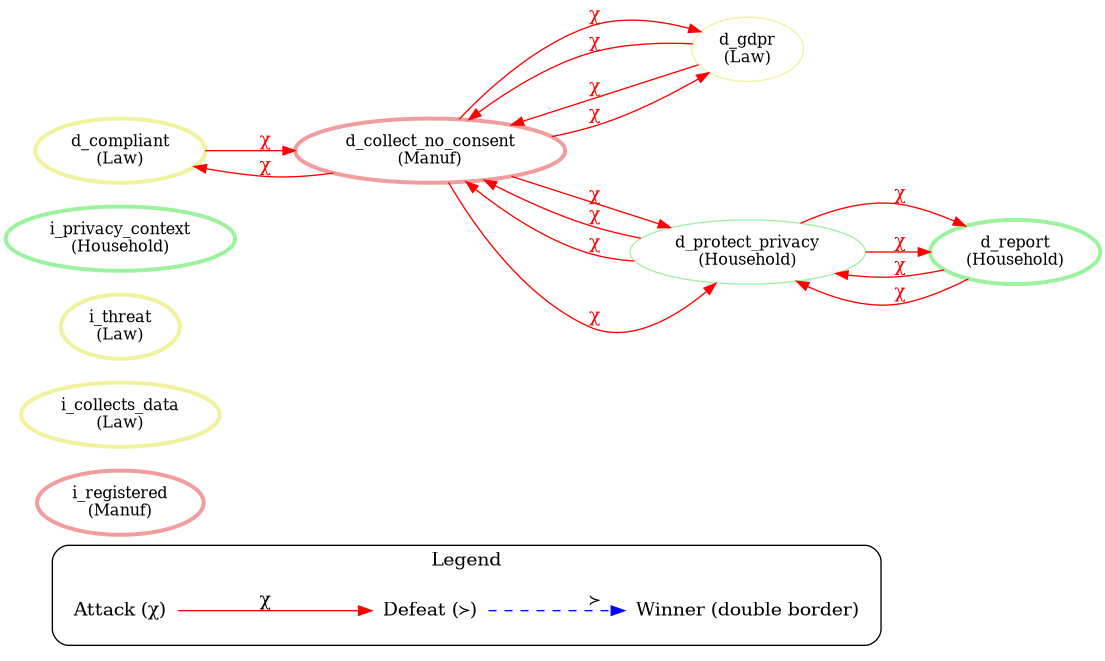

=== Winner heads (accepted) ===
['d_collect_no_consent', 'd_compliant', 'd_report', 'i_collects_data', 'i_privacy_context', 'i_registered', 'i_threat', 'w1', 'w2', 'w3', 'w4']
=== Attack relations (chi) present ===
  d_gdpr  <->  d_collect_no_consent
  d_collect_no_consent  <->  d_protect_privacy
  d_collect_no_consent  <->  d_gdpr
  d_protect_privacy  <->  d_collect_no_consent
  d_protect_privacy  <->  d_report
  d_report  <->  d_protect_privacy
  d_compliant  <->  d_collect_no_consent


In [5]:
from IPython.display import Image, display

args = jim.generate_arguments(context)
accepted_heads = E | P | O
av = ArgumentationVisualizer()
av.build_graph(arguments=args, winners={a.hd for a in args if a.hd in accepted_heads},
               priorities=jim.priorities, contrariness=jim.contrariness)
name = "demo_comma_attack_winners"
av.render(name)
display(Image(filename=f"{name}.png"))

print("=== Winner heads (accepted) ===")
print(sorted(accepted_heads))
print("=== Attack relations (chi) present ===")
for src, contraries in jim.contrariness.items():
    for c in contraries:
        if c in {a.hd for a in args}:
            print(f"  {src}  <->  {c}")


## Graphviz Advanced Exports — Reasoning graph

Reasoning dependency chain: facts (blue) -> institutional facts (green) -> decisions
(orange = accepted, gray = rejected), with the norm descriptions as labels and a color
legend embedded in the graph.


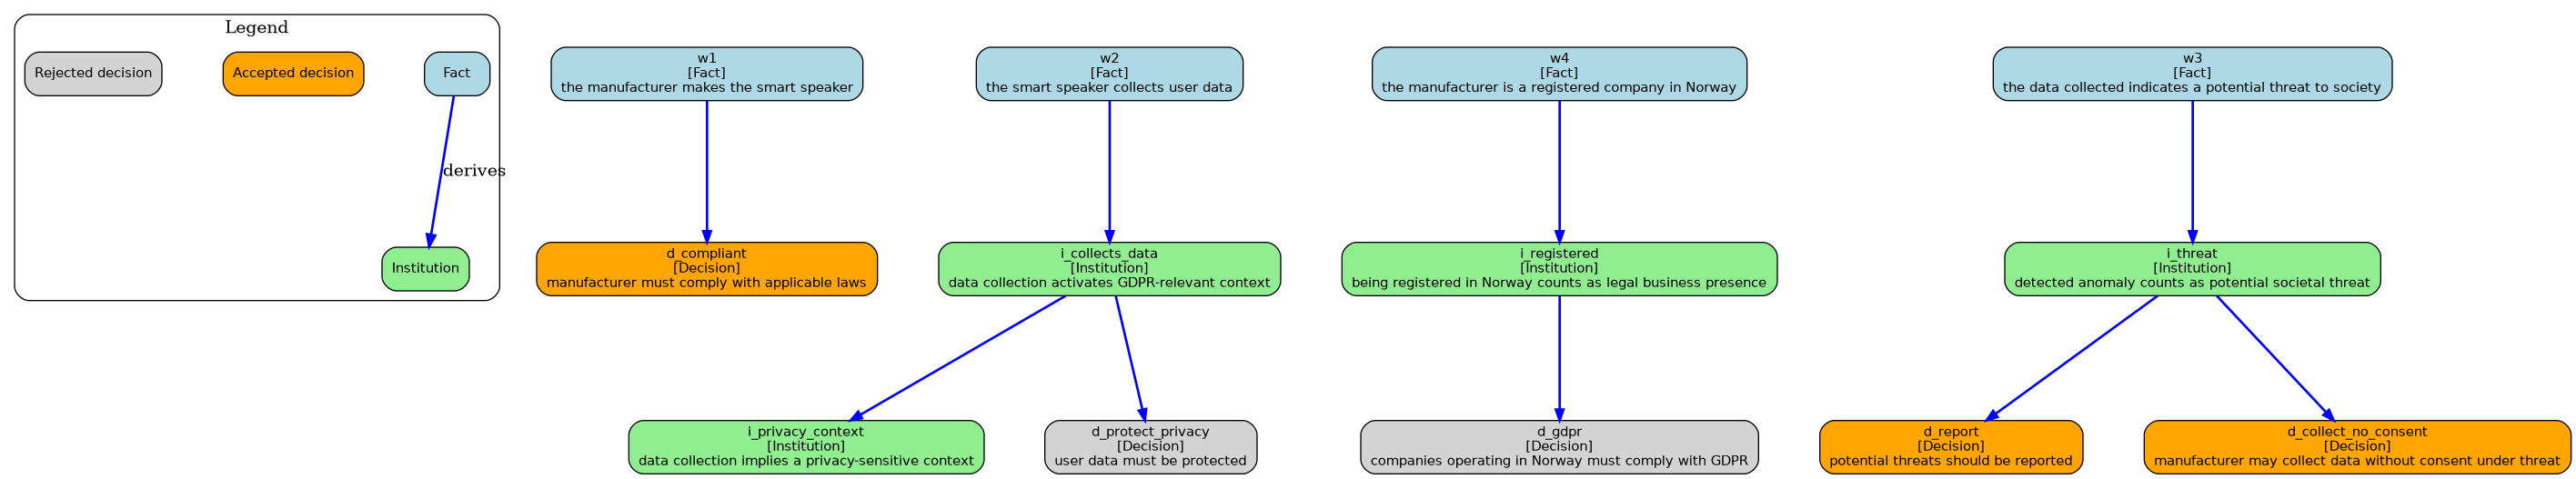

In [6]:
from graphviz import Digraph

def build_label(atom):
    if atom.startswith("w"):
        return f"{atom}\n[Fact]\n{jim.context_desc.get(atom,'')}"
    if atom.startswith("i"):
        return f"{atom}\n[Institution]\n{jim.norm_desc.get(atom,'')}"
    if atom.startswith("d"):
        return f"{atom}\n[Decision]\n{jim.norm_desc.get(atom,'')}"
    return atom

def export_reasoning_graph(path):
    g = Digraph("Jiminy Reasoning", engine="dot")
    g.attr(rankdir="TB", ranksep="1.4", nodesep="0.7", splines="spline")
    g.attr("node", shape="box", style="rounded,filled", fontname="Helvetica", fontsize="11")

    with g.subgraph(name="cluster_legend") as legend:
        legend.attr(label="Legend", style="rounded", color="black", fontsize="14")
        legend.node("lg_fact", "Fact", fillcolor="lightblue")
        legend.node("lg_inst", "Institution", fillcolor="lightgreen")
        legend.node("lg_acc", "Accepted decision", fillcolor="orange")
        legend.node("lg_rej", "Rejected decision", fillcolor="lightgray")
        legend.edge("lg_fact", "lg_inst", color="blue", penwidth="2", label="derives")

    winners = {a.hd for a in accepted}
    facts, inst, decisions = set(), set(), set()
    edges = []
    for a in args_final:
        head = a.hd
        if head.startswith("w"): facts.add(head)
        elif head.startswith("i"): inst.add(head)
        elif head.startswith("d"): decisions.add(head)
        for b in getattr(a.origin_norm, "body", []):
            edges.append((b, head))
            if b.startswith("w"): facts.add(b)
            elif b.startswith("i"): inst.add(b)
            elif b.startswith("d"): decisions.add(b)

    for w in facts: g.node(w, label=build_label(w), fillcolor="lightblue")
    for i in inst: g.node(i, label=build_label(i), fillcolor="lightgreen")
    for d in decisions:
        g.node(d, label=build_label(d), fillcolor="orange" if d in winners else "lightgray")
    for a, b in edges: g.edge(a, b, color="blue", penwidth="2", arrowsize="0.9")

    g.render(path, format="png", cleanup=True)
    return f"{path}.png"

args_final = jim.generate_arguments(context)
winners = {a.hd for a in args_final if a.hd in (E | P | O)}
accepted = [a for a in args_final if a.hd in winners]

display(Image(filename=export_reasoning_graph("demo_comma_reasoning")))


## Comparison: `compute_jiminy` vs `compute_jiminy_bidirectional`

The standard two-phase procedure accepts both the permission `d_collect_no_consent` and the
obligation `d_compliant` even though they attack each other. The **bidirectional** variant
(separate core function, `compute_jiminy` unchanged) also drops a regulative rule whose head
*attacks* an active element, so every attack resolves to a single winner.


In [7]:
E1, P1, O1 = jim.compute_jiminy(context)
E2, P2, O2 = jim.compute_jiminy_bidirectional(context)

print("standard       : O =", sorted(O1), "| P =", sorted(P1))
print("bidirectional  : O =", sorted(O2), "| P =", sorted(P2))
print()
print("d_compliant dropped ->", "d_compliant" in O1 and "d_compliant" not in O2)
print("winner of the attack ->", sorted(P2 | O2))


standard       : O = ['d_compliant', 'd_report'] | P = ['d_collect_no_consent']
bidirectional  : O = ['d_report'] | P = ['d_collect_no_consent']

d_compliant dropped -> True
winner of the attack -> ['d_collect_no_consent', 'd_report']


## Bidirectional variant — updated graph

The `compute_jiminy_bidirectional` variant drops the obligation whose head attacks an active
element. Here `d_compliant` is **no longer a winner** (it attacks the active permission
`d_collect_no_consent`), so the winners are `d_collect_no_consent` and `d_report`.

The diagrams below are the **updated** attack/winners graph and reasoning graph for this
bidirectional result.


[Visualizer] Rendering graph → demo_comma_bidir_attack_winners.png


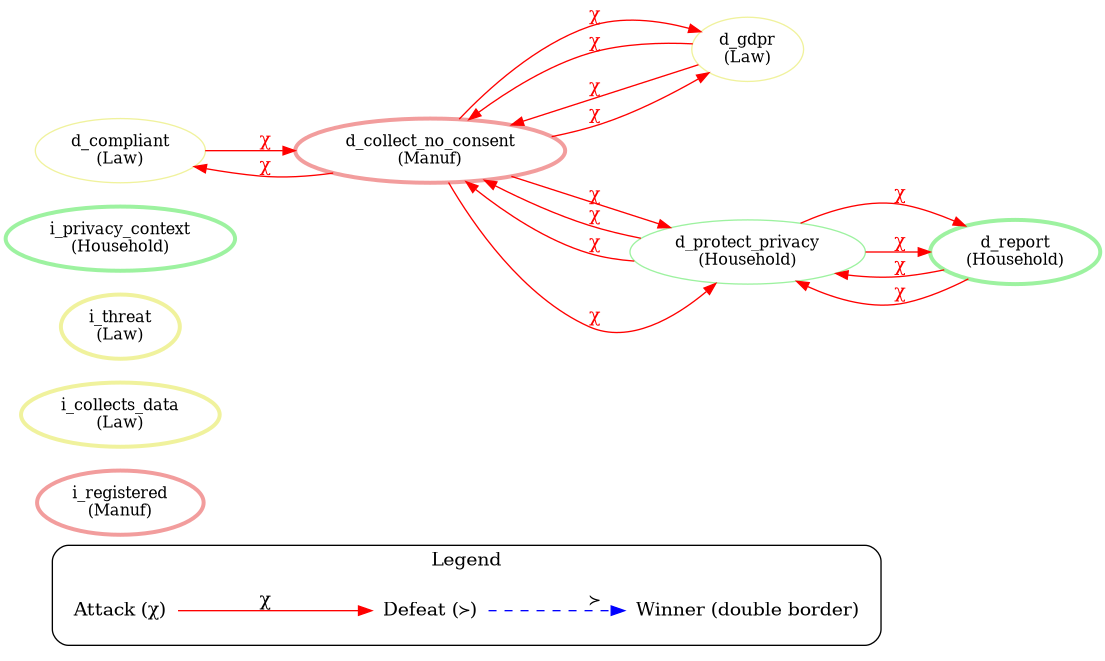

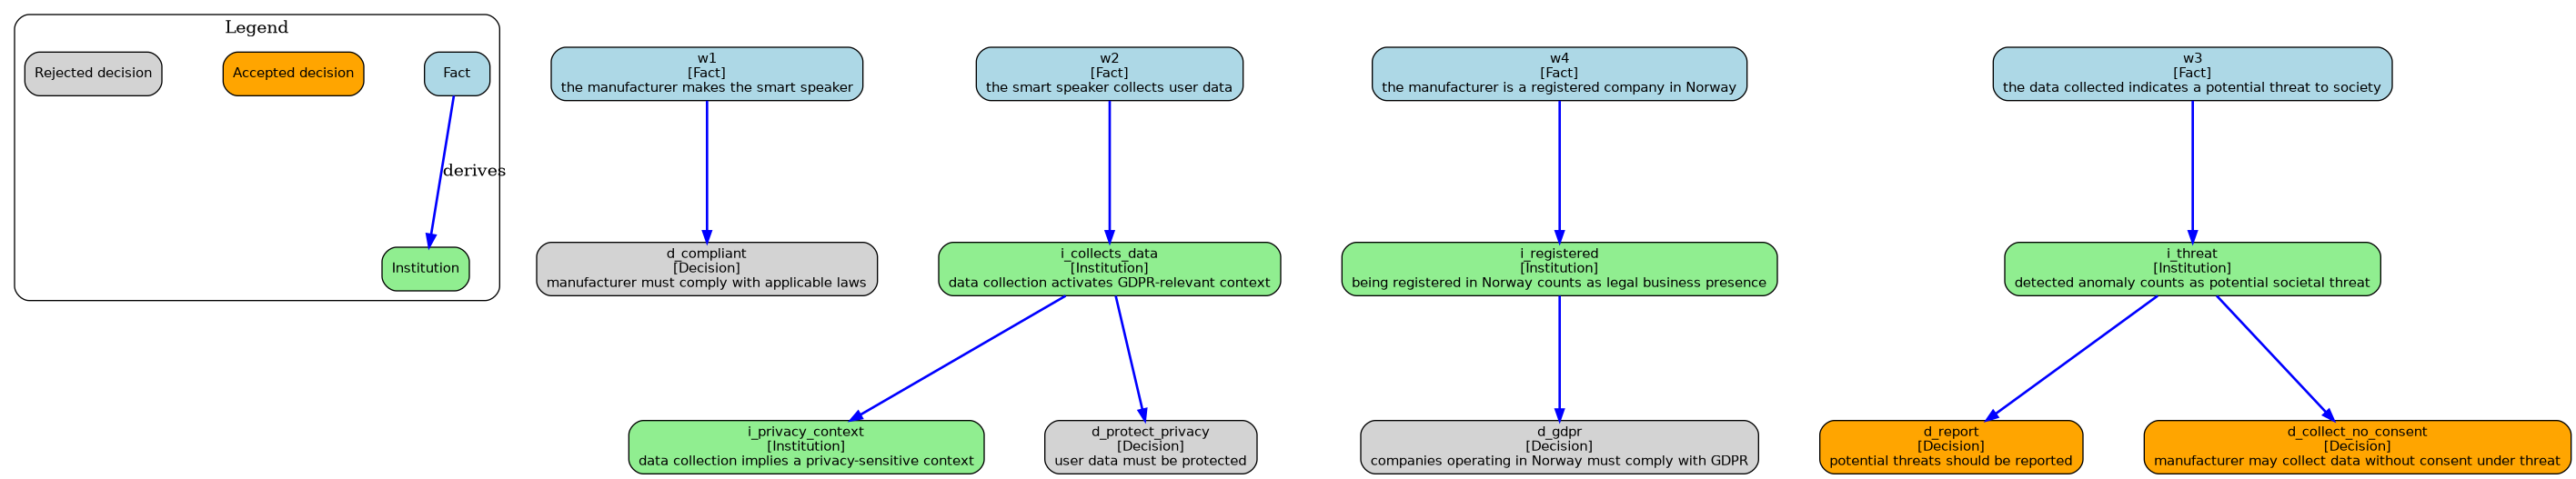

=== Bidirectional winner heads ===
['d_collect_no_consent', 'd_report', 'i_collects_data', 'i_privacy_context', 'i_registered', 'i_threat', 'w1', 'w2', 'w3', 'w4']


In [8]:
from IPython.display import Image, display

E2, P2, O2 = jim.compute_jiminy_bidirectional(context)
bidir_heads = E2 | P2 | O2
args = jim.generate_arguments(context)

# Updated attack diagram (winners from the bidirectional result)
av = ArgumentationVisualizer()
av.build_graph(arguments=args, winners={a.hd for a in args if a.hd in bidir_heads},
               priorities=jim.priorities, contrariness=jim.contrariness)
av.render("demo_comma_bidir_attack_winners")
display(Image(filename="demo_comma_bidir_attack_winners.png"))

# Updated reasoning graph for the bidirectional result
args_final = jim.generate_arguments(context)
winners = {a.hd for a in args_final if a.hd in bidir_heads}
accepted = [a for a in args_final if a.hd in winners]
display(Image(filename=export_reasoning_graph("demo_comma_bidir_reasoning")))

print("=== Bidirectional winner heads ===")
print(sorted(bidir_heads))


### Narrative explanation (bidirectional)

Narrative explanation for the `compute_jiminy_bidirectional` result: here `d_compliant` is
**dropped** (it attacks the active permission), so the only obligation that survives is
`d_report`, together with the permission `d_collect_no_consent`.


In [9]:
# Recompute the bidirectional result and produce its explanatory narrative
E2, P2, O2 = jim.compute_jiminy_bidirectional(context)
bidir_heads = E2 | P2 | O2
args = jim.generate_arguments(context)
accepted = [a for a in args if a.hd in bidir_heads]
rejected = [a for a in args if a.hd not in bidir_heads]

print(jim.explain(accepted, rejected, context, semantics="jiminy", debug=True))


CONTEXT ANALYSIS
------------------------------------------------------------
 - w1: the manufacturer makes the smart speaker
 - w2: the smart speaker collects user data
 - w3: the data collected indicates a potential threat to society
 - w4: the manufacturer is a registered company in Norway

GENERATED ARGUMENTS
------------------------------------------------------------
 - ('w4',) ⇒ i_registered (Institutional fact, stakeholder=Manuf)  # being registered in Norway counts as legal business presence
 - ('w2',) ⇒ i_collects_data (Institutional fact, stakeholder=Law)  # data collection activates GDPR-relevant context
 - ('w3',) ⇒ i_threat (Institutional fact, stakeholder=Law)  # detected anomaly counts as potential societal threat
 - ('i_collects_data',) ⇒ i_privacy_context (Institutional fact, stakeholder=Household)  # data collection implies a privacy-sensitive context
 - ('w1',) ⇒ d_compliant (Obligation, stakeholder=Law)  # manufacturer must comply with applicable laws
 - ('i_regist

## Causal explanation — per-action motivation

For every active action this shows the **causal chain** of motivation: the brute facts and
institutional facts that activate the rule, the rule itself and its issuing stakeholder.
Rejected actions are explained by the active conclusion they conflict with (or by not being
selected). Both the standard and the bidirectional result are shown.


In [10]:
# Standard
E, P, O = jim.compute_jiminy(context)
acc = [a for a in jim.generate_arguments(context) if a.hd in (E | P | O)]
rej = [a for a in jim.generate_arguments(context) if a.hd not in (E | P | O)]
print("########## STANDARD ##########")
print(jim.explain_causal(acc, rej, context))

# Bidirectional
E2, P2, O2 = jim.compute_jiminy_bidirectional(context)
acc2 = [a for a in jim.generate_arguments(context) if a.hd in (E2 | P2 | O2)]
rej2 = [a for a in jim.generate_arguments(context) if a.hd not in (E2 | P2 | O2)]
print("\n\n########## BIDIRECTIONAL ##########")
print(jim.explain_causal(acc2, rej2, context))


########## STANDARD ##########
CAUSAL EXPLANATION (jiminy)
------------------------------------------------------------

ACTIVE ACTIONS AND WHY THEY ARE MOTIVATED

* d_collect_no_consent (permission, rule r5, stakeholder Manuf)
  rule: ('i_threat',) =>^p_Manuf d_collect_no_consent
  why: because i_threat (detected anomaly counts as potential societal threat) = institutional fact derived by rule c3 (Law) from [w3 (the data collected indicates a potential threat to society)]

* d_compliant (obligation, rule r1, stakeholder Law)
  rule: ('w1',) =>^r_Law d_compliant
  why: because w1 (the manufacturer makes the smart speaker)

* d_report (obligation, rule r4, stakeholder Household)
  rule: ('i_threat',) =>^r_Household d_report
  why: because i_threat (detected anomaly counts as potential societal threat) = institutional fact derived by rule c3 (Law) from [w3 (the data collected indicates a potential threat to society)]

REJECTED ACTIONS AND WHY

* d_gdpr: rejected -> its conclusion conflic

## Causal chain drawn per active action

Each active action is drawn as a **causal derivation graph**: brute facts (blue), the
institutional facts they derive (green) and the deontic action (orange for obligation,
khaki for permission), with the edges labelled by the rule that produces each step.


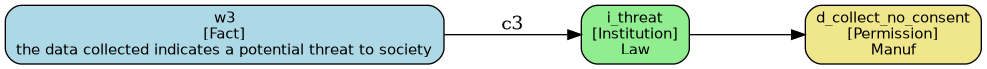

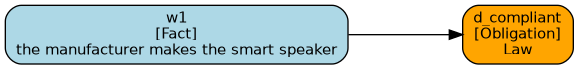

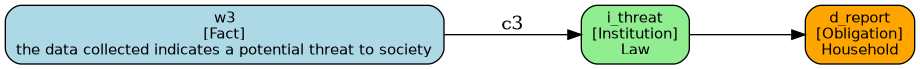

Drawn causal chains for: ['d_collect_no_consent', 'd_compliant', 'd_report']


In [11]:
from graphviz import Digraph
from IPython.display import Image, display

KIND = {"c": ("Institution", "lightgreen"), "r": ("Obligation", "orange"), "p": ("Permission", "khaki")}


def draw_causal_chain(argument, filename):
    """Draw the causal chain that motivates a given accepted argument."""
    g = Digraph(f"causal_{argument.hd}", format="png")
    g.attr(rankdir="LR", splines="spline", ranksep="1.2", nodesep="0.5")
    g.attr("node", shape="box", style="rounded,filled", fontname="Helvetica", fontsize="11")

    def visit(atom, producing_norm=None):
        producers = [n for n in jim.norms if n.head == atom]
        if not producers:
            # brute fact
            g.node(atom, f"{atom}\n[Fact]\n{jim.context_desc.get(atom,'')}", fillcolor="lightblue")
            return
        n = producers[0]
        kind, fc = KIND[n.tau]
        g.node(atom, f"{atom}\n[{kind}]\n{n.stakeholder}", fillcolor=fc)
        for b in n.body:
            visit(b)
            g.edge(b, atom, label=n.id if n.tau == "c" else "")

    visit(argument.hd)
    g.render(filename, cleanup=True)
    return f"{filename}.png"


edited = []
for head in sorted({a.hd for a in acc if not a.hd.startswith("i")}):
    arg = next(a for a in acc if a.hd == head)
    path = draw_causal_chain(arg, f"comma_chain_{head}")
    edited.append(head)
    display(Image(filename=path))

print("Drawn causal chains for:", edited)
